<a href="https://colab.research.google.com/github/Sitinurhafsah/Praktikum4_TugasMandiri_AI/blob/main/Siti%20Nurhafsah_230705103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix
from nltk.tokenize import word_tokenize
from keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.models import Model
from keras.layers import Input, Dense, LSTM, Dropout, concatenate
from keras.layers import Embedding
from keras.utils import plot_model

In [3]:
df = pd.read_csv('/content/all_agree.csv')
df.head()

,title,label,label_score
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",non-clickbait,0
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,non-clickbait,0
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,clickbait,1
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",non-clickbait,0
4,MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...,non-clickbait,0


In [4]:
df['label_score'].value_counts()

,count
label_score,
0,5297
1,3316


In [5]:
def find_punc(x, punc):
  count = 0
  for char in x:
      if char == punc:
          count += 1
  return count

In [6]:
df['ccount'] = df['title'].apply(lambda x: find_punc(x, ','))
df['klctop_count'] = df['title'].apply(lambda x: find_punc(x, '.'))
df['excl_mark_count'] = df['title'].apply(lambda x: find_punc(x, '!'))
df['que_mark_count'] = df['title'].apply(lambda x: find_punc(x, '?'))
df['col_count'] = df['title'].apply(lambda x: find_punc(x, ':'))
df['semi_col_count'] = df['title'].apply(lambda x: find_punc(x, ';'))
df['sq_col_count'] = df['title'].apply(lambda x: find_punc(x, "'"))

In [7]:
df.shape

(8613, 10)

In [8]:
def find_uppercase(x):
    count = 0
    for char in x:
        if char.isupper() :
            count +=1
    return count

def find_lowercase(x):
    count = 0
    for char in x:
        if char.islower() :
            count += 1
    return count

def find_number(x):
    return len(re.findall('[0-9]', x))


In [9]:
df['uppercase_count'] = df['title'].apply(find_uppercase)
df['lowercase_count'] = df['title'].apply(find_lowercase)
df['number_count'] = df['title'].apply(find_number)

In [10]:
df.shape

(8613, 13)

In [11]:
import nltk
nltk.download('punkt_tab', quiet=True)

def clean(text) :
  # Lowering letters
  text = text.lower()
  # Removing Punctuations
  text = re.sub ('[,.!?:;\']',  '', text)
  # Tokenization
  word_tokens = word_tokenize(text)
  # Joining words
  text = (''.join(word_tokens))
  return text

In [12]:
df['cleaned_title'] = df ['title'].apply(clean)

In [13]:
df [['title', 'cleaned_title']]

,title,cleaned_title
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",masukradarpilwalkotmedanmenantujokowibertemudp...
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,malaysiasudutkanriisukabutasaphinggainvasibabi
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,viraldriverojoldibekasiantarpesananmakananpaka...
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",kemensossalurkanrp73mbagikorbankerusuhansosial...
4,MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...,mpramandemenuud1945takakanmelebarkemana-mana
...,...,...
8608,Twice Rilis Teaser MV 'Feel Special' Jelang Co...,twicerilisteasermvfeelspecialjelangcomebackkon...
8609,"Asap Karhutla Riau Mulai Merambah Ke Nias, BM...",asapkarhutlariaumulaimerambahkeniasbmkgimbauwa...
8610,"Tolak RUU Pertanahan, Ribuan Petani Siap Gelar...",tolakruupertanahanribuanpetanisiapgelaraksidii...
8611,Ada Niat Tambah Momongan Tanpa Ikut Program Ha...,adaniattambahmomongantanpaikutprogramhamilfedi...


In [14]:
df.columns

Index(['title', 'label', 'label_score', 'ccount', 'klctop_count',
       'excl_mark_count', 'que_mark_count', 'col_count', 'semi_col_count',
       'sq_col_count', 'uppercase_count', 'lowercase_count', 'number_count',
       'cleaned_title'],
      dtype='object')

In [15]:
X = df.iloc [:,3:]
y = df.iloc [:,2]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2,
random_state=77)

In [17]:
print (X_train.shape)
print (X_test.shape)

(6890, 11)
(1723, 11)


In [19]:
X_train_title = X_train ['cleaned_title']
X_test_title = X_test ['cleaned_title']

X_train_punc = X_train.drop ('cleaned_title', axis = 1)
X_test_punc = X_test.drop ('cleaned_title', axis = 1)

In [20]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_title)

X_train_title = tokenizer.texts_to_sequences(X_train_title)
X_test_title = tokenizer.texts_to_sequences(X_test_title)

In [21]:
tokenizer.word_index

{'gara': 1,
 'timnasu': 2,
 'garaini': 3,
 '0': 4,
 '1': 5,
 'undang': 6,
 'timnasindonesiau': 7,
 '16': 8,
 'surabayamenggugat': 9,
 '2020': 10,
 '3': 11,
 'cukainaik23': 12,
 'hati': 13,
 'topikpagi': 14,
 'pdi': 15,
 'siap': 16,
 'hutke': 17,
 'diawasidihongkongaktivisjoshuawongterbangkeberlin': 18,
 'anak': 19,
 'maruf': 20,
 'x': 21,
 'hatta': 22,
 'zodiakmingguan16': 23,
 '2019': 24,
 '162020': 25,
 'pemerintah': 26,
 'leeminjung': 27,
 'habisan': 28,
 'luka': 29,
 'tahundepanadakebijakancukaibaruapasajaisinya': 30,
 'kejang': 31,
 'garahalini': 32,
 'junu': 33,
 'cerai': 34,
 'demokratsiapbantupemerintahanjokowi': 35,
 'emak': 36,
 'timorleste': 37,
 'jadwalbolaakhirpekanligainggrisligaspanyolligaitalia': 38,
 'gram': 39,
 '11': 40,
 'ksditunda': 41,
 'videodetik': 42,
 'aksi': 43,
 'undangkpk': 44,
 'pembangunansekolahindonesia': 45,
 'madiun': 46,
 'blak': 47,
 'usd': 48,
 'coba': 49,
 'kis': 50,
 'kemkominfososialisasikanmanfaatbantuansosialkepadakpmbpnt': 51,
 'pkh': 52,
 '2

In [22]:
vocab_size = len(tokenizer.word_index)
vocab_size

7735

In [23]:
lengths = []
for sentence in X_train_title:
    lengths.append(len(sentence))

print('Longest sentence\t:', max(lengths))
print('Shortest sentence\t:', min(lengths))
print('Average length\t\t:', np.mean(lengths))

Longest sentence	: 6
Shortest sentence	: 1
Average length		: 1.1435413642960812


In [24]:
X_train_title = sequence.pad_sequences(X_train_title, maxlen=19)
X_test_title = sequence.pad_sequences(X_test_title, maxlen=19)

In [25]:
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_train.values)
class_weights

array([0.80868545, 1.30988593])

In [26]:
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.8086854460093896), 1: np.float64(1.3098859315589353)}

In [27]:
print(X_train_title.shape)
print(X_test_title.shape)

(6890, 19)
(1723, 19)


In [28]:
tf.random.set_seed(99)

lstm_input = Input(shape=(19,))
lstm = Embedding(input_dim=vocab_size+1, output_dim=32)(lstm_input)
lstm = LSTM(3)(lstm)
lstm = Dropout(rate=0.5)(lstm)
lstm = Dense(3, activation='sigmoid')(lstm)

lstm_model = Model(inputs=lstm_input, outputs=lstm)

In [29]:
dense_input = Input(shape=(10,))
dense = Dropout(rate=0.5) (dense_input)
dense = Dense(3, activation='sigmoid') (dense)
dense_model = Model(inputs=dense_input, outputs=dense)

In [30]:
print(X_train_punc.shape)
print(X_test_punc.shape)

(6890, 10)
(1723, 10)


In [31]:
concat = concatenate ([lstm_model.output, dense_model.output])
concat = Dense(6, activation='sigmoid')(concat)
concat = Dense(1, activation='sigmoid')(concat)
model = Model(inputs=[lstm_model.input, dense_model.input], outputs=concat)

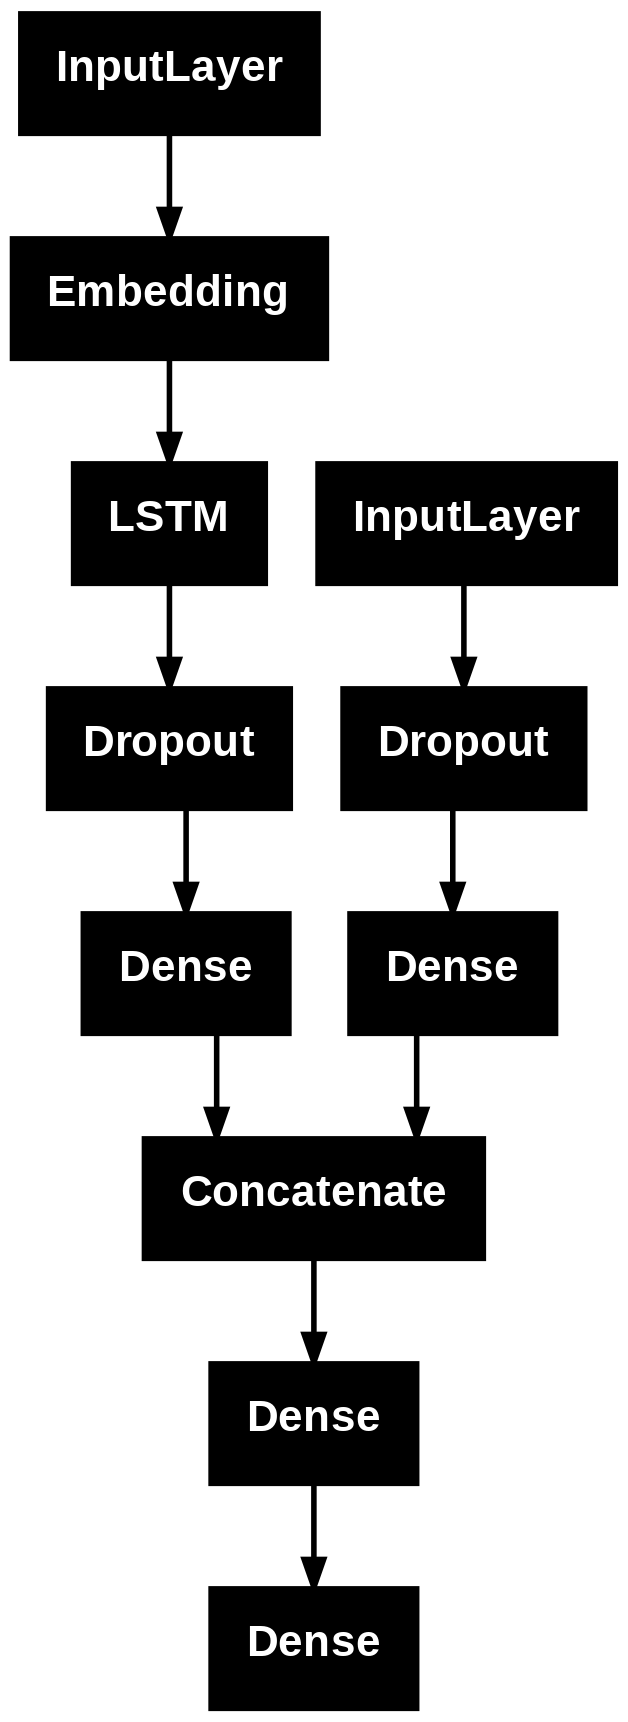

In [32]:
plot_model(model)

In [33]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [34]:
history = model.fit(
    [X_train_title, X_train_punc],
    y_train,
    epochs=4,
    batch_size=64, class_weight=class_weight_dict,
    validation_data=([X_test_title, X_test_punc], y_test))


Epoch 1/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4769 - loss: 0.6935 - val_accuracy: 0.4045 - val_loss: 0.6962
Epoch 2/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4734 - loss: 0.6928 - val_accuracy: 0.4074 - val_loss: 0.6964
Epoch 3/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5422 - loss: 0.6894 - val_accuracy: 0.4498 - val_loss: 0.6926
Epoch 4/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6019 - loss: 0.6787 - val_accuracy: 0.4997 - val_loss: 0.6899


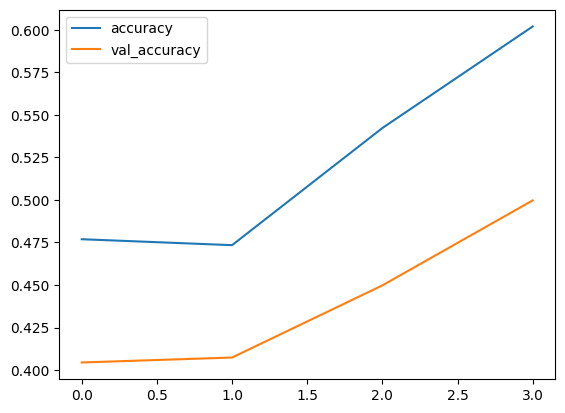

In [36]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['accuracy', 'val_accuracy'])

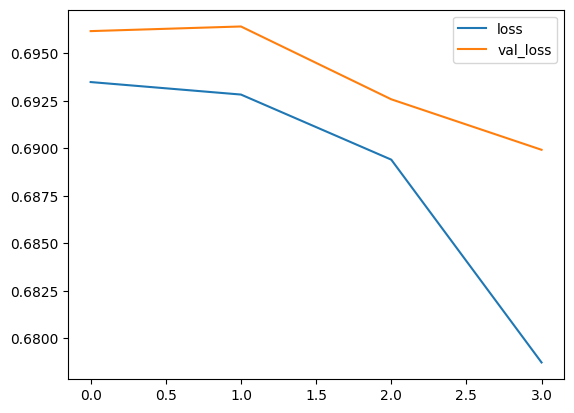

In [37]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss','val_loss'])